# AI Recommendation System Using MovieLens 100K

This notebook builds, evaluates, and tunes a collaborative filtering recommender on the
MovieLens 100K dataset, then generates top-N recommendations.

## Objectives
1. Understand recommendation systems and collaborative filtering
2. Explore and preprocess the MovieLens 100K dataset
3. Split the data into training and test sets
4. Train an SVD collaborative filtering model
5. Evaluate the model with RMSE and MAE
6. Tune hyperparameters with `GridSearchCV`
7. Generate top-N recommendations for each user
8. Reflect on ethical considerations

**How to run:** open in Google Colab and choose *Runtime > Run all*. A full run takes a few minutes.
All random seeds are fixed (`SEED = 42`) so the numbers below reproduce exactly.

---
# 1. Understanding Recommendation Systems

**Collaborative filtering** predicts what a user will like from the ratings that users have
given to items. It uses only the user-item interaction matrix, not any description of the items.

- **User-based:** recommend items liked by users whose rating history resembles yours.
- **Item-based:** recommend items that tend to be rated similarly to items you already liked
  (Sarwar et al., 2001).

**Collaborative vs. content-based filtering**

| | Collaborative filtering | Content-based filtering |
|---|---|---|
| Uses | Ratings from all users | Item attributes (genre, cast, tags) |
| Core assumption | Users who agreed in the past will agree again | You will like items similar to ones you liked |
| Strength | Finds surprising items; needs no item metadata | Works for brand-new items |
| Weakness | Cold start: cannot handle a new user or item | Recommendations stay narrow |

This project uses **matrix factorization (SVD)**, which learns a small set of latent factors for
each user and each movie instead of comparing users or items directly (Koren et al., 2009).

## Setup

In [1]:
# Colab: install the libraries (already present in most environments)
!pip install -q scikit-surprise pandas matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from surprise import Dataset, SVD, BaselineOnly, NormalPredictor, accuracy
from surprise.model_selection import train_test_split, cross_validate, GridSearchCV, KFold

SEED = 42            # fixed so every run gives the same numbers
np.random.seed(SEED)
sns.set_style("whitegrid")
print("Setup complete.")

Setup complete.


---
# 2. Data Exploration and Preprocessing

MovieLens 100K contains ratings that users gave to movies, collected by the GroupLens research
group (Harper & Konstan, 2015).

In [3]:
# Load the built-in MovieLens 100K dataset and convert it to a DataFrame for exploration
data = Dataset.load_builtin("ml-100k", prompt=False)
ratings = pd.DataFrame(data.raw_ratings, columns=["user_id", "item_id", "rating", "timestamp"])
ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596


In [4]:
print("Number of ratings :", len(ratings))
print("Unique users      :", ratings["user_id"].nunique())
print("Unique movies     :", ratings["item_id"].nunique())
print("Rating range      :", ratings["rating"].min(), "to", ratings["rating"].max())

Number of ratings : 100000
Unique users      : 943
Unique movies     : 1682
Rating range      : 1.0 to 5.0


### Data cleaning: missing values, duplicates, and data types

In [5]:
# Inspect the data types BEFORE cleaning
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   user_id    100000 non-null  object 
 1   item_id    100000 non-null  object 
 2   rating     100000 non-null  float64
 3   timestamp  100000 non-null  object 
dtypes: float64(1), object(3)
memory usage: 3.1+ MB


In [6]:
# Check for missing values and duplicates
print("Missing values per column:")
print(ratings.isna().sum())
print("\nExact duplicate rows            :", ratings.duplicated().sum())
print("Duplicate (user_id, item_id) pairs:", ratings.duplicated(subset=["user_id", "item_id"]).sum())

Missing values per column:
user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

Exact duplicate rows            : 0
Duplicate (user_id, item_id) pairs: 0


The dataset has no missing values and no duplicate ratings, so no rows are dropped. However,
`info()` shows that **user_id, item_id, and timestamp were loaded as text (object) columns**.
The project requires user and item IDs to be integers and ratings to be floats, so we convert them.

In [7]:
# Data cleaning and type conversion
ratings = ratings.drop_duplicates()
ratings = ratings.dropna()

ratings["user_id"] = ratings["user_id"].astype(int)
ratings["item_id"] = ratings["item_id"].astype(int)
ratings["rating"] = ratings["rating"].astype(float)
ratings["timestamp"] = pd.to_datetime(ratings["timestamp"].astype(int), unit="s")

# Confirm the corrected data types
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   user_id    100000 non-null  int64         
 1   item_id    100000 non-null  int64         
 2   rating     100000 non-null  float64       
 3   timestamp  100000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 3.1 MB


### Summary statistics and sparsity

In [8]:
display(ratings[["rating"]].describe().T)

n_ratings = len(ratings)
n_users = ratings["user_id"].nunique()
n_items = ratings["item_id"].nunique()
sparsity = 1 - n_ratings / (n_users * n_items)

print(f"Mean rating      : {ratings['rating'].mean():.3f} (SD = {ratings['rating'].std():.3f})")
print(f"Possible pairs   : {n_users * n_items:,}")
print(f"Observed ratings : {n_ratings:,}")
print(f"Matrix sparsity  : {sparsity:.2%} empty")
print(f"Date range       : {ratings['timestamp'].min().date()} to {ratings['timestamp'].max().date()}")

,count,mean,std,min,25%,50%,75%,max
rating,100000.0,3.52986,1.125674,1.0,3.0,4.0,4.0,5.0


Mean rating      : 3.530 (SD = 1.126)
Possible pairs   : 1,586,126
Observed ratings : 100,000
Matrix sparsity  : 93.70% empty
Date range       : 1997-09-20 to 1998-04-22


In [9]:
# Percentage of ratings at each star level
rating_counts = ratings["rating"].value_counts().sort_index()
rating_pct = (rating_counts / n_ratings * 100).round(1)
print("Share of each rating value (%):")
print(rating_pct.to_string())
print(f"\nRatings of 3 or higher: {rating_pct.loc[[3.0, 4.0, 5.0]].sum():.1f}%")

Share of each rating value (%):
rating
1.0     6.1
2.0    11.4
3.0    27.1
4.0    34.2
5.0    21.2

Ratings of 3 or higher: 82.5%


In [10]:
# How much activity does each user and each movie have?
per_user = ratings.groupby("user_id").size()
per_item = ratings.groupby("item_id").size()

print(f"Ratings per user : min {per_user.min()}, median {per_user.median():.0f}, max {per_user.max()}")
print(f"Ratings per movie: min {per_item.min()}, median {per_item.median():.0f}, max {per_item.max()}")
print(f"Movies with only one rating: {(per_item == 1).sum()}")

top_10pct = per_item.sort_values(ascending=False).head(int(n_items * 0.1)).sum()
print(f"Share of all ratings going to the most-rated 10% of movies: {top_10pct / n_ratings:.1%}")

Ratings per user : min 20, median 65, max 737
Ratings per movie: min 1, median 27, max 583
Movies with only one rating: 141
Share of all ratings going to the most-rated 10% of movies: 42.7%


### Visualising the distributions

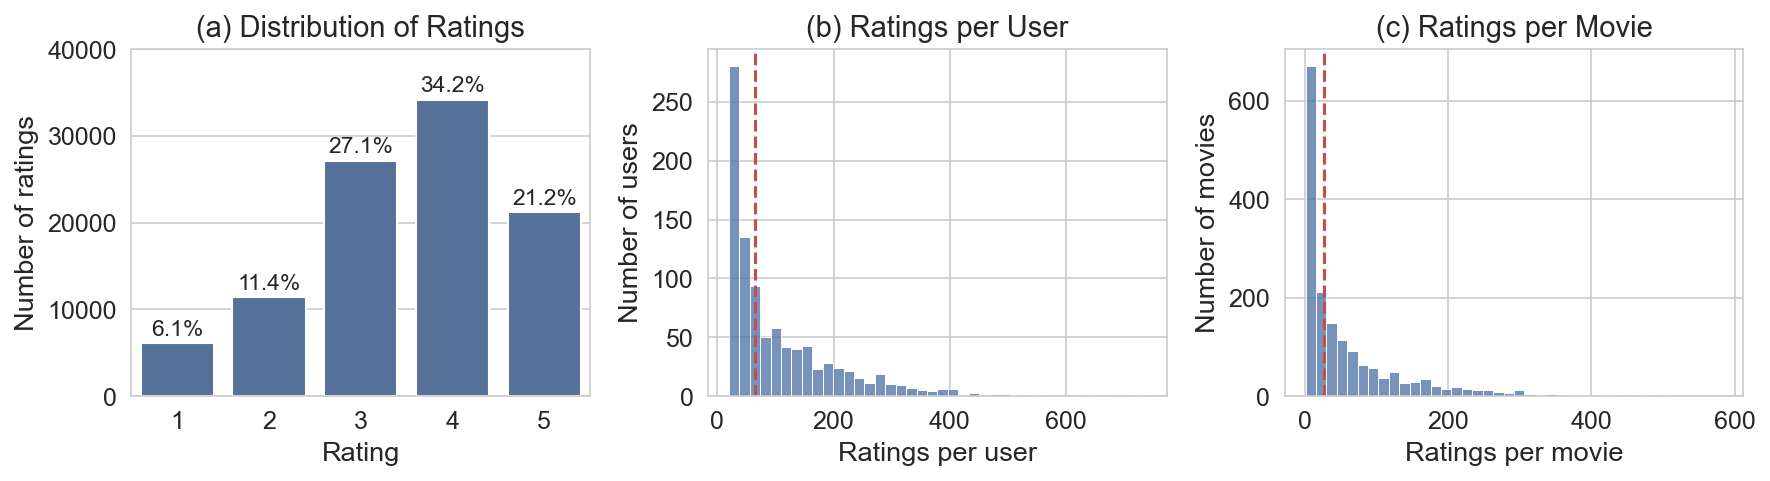

In [11]:
plt.rcParams.update({"font.size": 13, "axes.titlesize": 14, "axes.labelsize": 13,
                     "xtick.labelsize": 12, "ytick.labelsize": 12})
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), dpi=150)

# (a) Distribution of rating values
sns.barplot(x=rating_counts.index.astype(int), y=rating_counts.values, ax=axes[0], color="#4a6fa5")
for i, (count, pct) in enumerate(zip(rating_counts.values, rating_pct.values)):
    axes[0].text(i, count + 900, f"{pct:.1f}%", ha="center", fontsize=11)
axes[0].set(title="(a) Distribution of Ratings", xlabel="Rating", ylabel="Number of ratings")
axes[0].set_ylim(0, 40000)

# (b) Ratings per user
sns.histplot(per_user, bins=40, ax=axes[1], color="#4a6fa5")
axes[1].axvline(per_user.median(), color="#c0504d", linestyle="--")
axes[1].set(title="(b) Ratings per User", xlabel="Ratings per user", ylabel="Number of users")

# (c) Ratings per movie
sns.histplot(per_item, bins=40, ax=axes[2], color="#4a6fa5")
axes[2].axvline(per_item.median(), color="#c0504d", linestyle="--")
axes[2].set(title="(c) Ratings per Movie", xlabel="Ratings per movie", ylabel="Number of movies")

plt.tight_layout()
plt.show()

**What the exploration shows**

1. **Ratings skew positive.** Most ratings are 3 stars or higher and very few are 1s. People
   mostly rate movies they chose to watch, so this is not a random sample of opinion.
2. **The rating matrix is extremely sparse** (about 94% empty). The model must generalise from
   very few observations per person, which is the central difficulty of the task.
3. **Activity is long-tailed on both sides.** Every user has at least 20 ratings because
   GroupLens filtered the data that way, but most users rate far fewer movies than the most
   active ones. Movies are even more uneven: a small group of popular titles absorbs a large
   share of all ratings, while many movies have only a single rating. A model trained on this
   will tend to favour already-popular films, which matters for fairness (see Section 8).

---
# 3. Data Splitting

The data are split 75/25. The model learns from the training set only; the test set is held back
so we can measure how well it generalises to ratings it has never seen. `random_state=SEED`
makes the split reproducible.

In [12]:
trainset, testset = train_test_split(data, test_size=0.25, random_state=SEED)
print("Training ratings:", trainset.n_ratings)
print("Test ratings    :", len(testset))

Training ratings: 75000
Test ratings    : 25000


---
# 4. Model Selection

**SVD (singular value decomposition)** represents each user and each movie as a short vector of
latent factors. It predicts a rating as the global mean, plus a user bias, plus a movie bias,
plus the dot product of the two factor vectors, fitting all of these by stochastic gradient
descent (Koren et al., 2009).

In [13]:
model = SVD(random_state=SEED)
model.fit(trainset)
print("Trained SVD with", model.n_factors, "latent factors and", model.n_epochs, "epochs.")

Trained SVD with 100 latent factors and 20 epochs.


---
# 5. Model Evaluation

Accuracy is measured with **RMSE**, which penalises large errors heavily, and **MAE**, the
average absolute error. Both are expressed in rating stars, so lower is better
(Herlocker et al., 2004).

In [14]:
predictions = model.test(testset)

rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)
print(f"Root Mean Squared Error: {rmse}")

RMSE: 0.9396
MAE:  0.7408
Root Mean Squared Error: 0.9395567173787086


### Is that good? Comparing against reference models

An RMSE only means something next to a benchmark, so we train two reference models on the same
split: a **random predictor**, and a **baseline** that uses nothing but user and movie biases
(how generously a user rates, and how well liked a movie is).

In [15]:
results = []
for name, algo in [("Random predictor", NormalPredictor()),
                   ("Baseline (user + movie biases)", BaselineOnly(verbose=False)),
                   ("SVD (default settings)", SVD(random_state=SEED))]:
    np.random.seed(SEED)          # NormalPredictor draws at random; seed it for reproducibility
    algo.fit(trainset)
    preds = algo.test(testset)
    results.append({"Model": name,
                    "RMSE": round(accuracy.rmse(preds, verbose=False), 4),
                    "MAE": round(accuracy.mae(preds, verbose=False), 4)})

comparison = pd.DataFrame(results)
display(comparison)

,Model,RMSE,MAE
0,Random predictor,1.5181,1.2176
1,Baseline (user + movie biases),0.9474,0.7511
2,SVD (default settings),0.9396,0.7408


### Cross-validation

A single split could be lucky, so we also run 5-fold cross-validation.

> **Important:** `cross_validate` must be given a **fresh, unfitted** model. Passing the model
> that was already fitted above re-trains it on 80% of the *entire* dataset, including most of
> the test ratings. Any RMSE computed on `testset` afterwards would then be measured on data the
> model had already seen, producing a falsely low score of around 0.74 instead of the true 0.94.

In [16]:
# KFold is seeded too, otherwise the folds (and the numbers below) change every run
cv_results = cross_validate(SVD(random_state=SEED), data, measures=["RMSE", "MAE"],
                            cv=KFold(n_splits=5, random_state=SEED, shuffle=True), verbose=True)

print(f"\nMean CV RMSE: {cv_results['test_rmse'].mean():.4f} "
      f"(SD = {cv_results['test_rmse'].std():.4f})")
print(f"Mean CV MAE : {cv_results['test_mae'].mean():.4f} "
      f"(SD = {cv_results['test_mae'].std():.4f})")

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9346  0.9317  0.9416  0.9318  0.9352  0.9350  0.0036  
MAE (testset)     0.7376  0.7345  0.7417  0.7347  0.7375  0.7372  0.0026  
Fit time          1.17    1.27    1.23    1.29    1.24    1.24    0.04    
Test time         0.12    0.13    0.25    0.12    0.13    0.15    0.05    

Mean CV RMSE: 0.9350 (SD = 0.0036)
Mean CV MAE : 0.7372 (SD = 0.0026)


---
# 6. Hyperparameter Tuning

`GridSearchCV` searches combinations of the number of latent factors, the number of training
passes, and the learning rate, scoring each by cross-validated RMSE.

In [17]:
param_grid = {"n_factors": [50, 100], "n_epochs": [20, 40], "lr_all": [0.002, 0.005]}
grid_search = GridSearchCV(SVD, param_grid, measures=["rmse"],
                           cv=KFold(n_splits=3, random_state=SEED, shuffle=True))
grid_search.fit(data)

print("Best parameters:", grid_search.best_params["rmse"])
print(f"Best cross-validated RMSE: {grid_search.best_score['rmse']:.4f}")

Best parameters: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005}
Best cross-validated RMSE: 0.9443


In [18]:
# Re-train the best configuration on the training set and score it on the held-out test set
best_params = grid_search.best_params["rmse"]
tuned_model = SVD(random_state=SEED, **best_params)
tuned_model.fit(trainset)
tuned_predictions = tuned_model.test(testset)

tuned_rmse = accuracy.rmse(tuned_predictions, verbose=False)
tuned_mae = accuracy.mae(tuned_predictions, verbose=False)
print(f"Tuned SVD  - test RMSE: {tuned_rmse:.4f}, MAE: {tuned_mae:.4f}")
print(f"Default SVD- test RMSE: {rmse:.4f}, MAE: {mae:.4f}")
print(f"Improvement: {(rmse - tuned_rmse) / rmse:.2%}")

Tuned SVD  - test RMSE: 0.9404, MAE: 0.7416
Default SVD- test RMSE: 0.9396, MAE: 0.7408
Improvement: -0.09%


**Interpreting the tuning result.** The grid's best configuration scores essentially the same as
the default settings on the held-out test set - the difference is far smaller than the spread
between cross-validation folds, so it is noise rather than a real gain. This is a useful negative
result: the default SVD was already near the ceiling for what this grid can reach, and further
accuracy would have to come from a different model or from extra signal (such as movie genres or
rating timestamps), not from these three hyperparameters. Note also that the grid's best
cross-validated RMSE is not directly comparable with the 5-fold figure above, because the search
uses 3 folds.

---
# 7. Top-N Recommendations

A recommendation must be for a movie the user has **not already rated**. Surprise builds this
set with `build_anti_testset()`, which lists every user-movie pair *missing* from the training
data. We predict a rating for each pair and keep each user's 10 highest predictions.

In [19]:
def get_top_n(predictions, n=10):
    """Return {user_id: [(item_id, predicted_rating), ...]} keeping each user's top n."""
    top_n = {}
    for uid, iid, true_r, est, _ in predictions:
        top_n.setdefault(uid, []).append((iid, est))

    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

In [20]:
# Every (user, movie) pair the user has NOT rated
anti_testset = trainset.build_anti_testset()
print(f"Unrated user-movie pairs to score: {len(anti_testset):,}")

anti_predictions = tuned_model.test(anti_testset)
top_n = get_top_n(anti_predictions, n=10)
print(f"Generated top-10 recommendations for {len(top_n)} users.")

Unrated user-movie pairs to score: 1,475,292


Generated top-10 recommendations for 943 users.


In [21]:
# Map movie IDs to titles so the recommendations are readable
import os
from surprise.builtin_datasets import get_dataset_dir

item_file = os.path.join(get_dataset_dir(), "ml-100k", "ml-100k", "u.item")
movie_titles = pd.read_csv(item_file, sep="|", header=None, encoding="latin-1",
                           usecols=[0, 1], names=["item_id", "title"])
id_to_title = dict(zip(movie_titles["item_id"].astype(str), movie_titles["title"]))

for uid in list(top_n)[:3]:
    print(f"\nTop 10 recommendations for user {uid}:")
    for rank, (iid, est) in enumerate(top_n[uid], 1):
        print(f"  {rank:2d}. {id_to_title.get(iid, 'Unknown'):<45s} predicted {est:.2f}")


Top 10 recommendations for user 877:
   1. Close Shave, A (1995)                         predicted 4.72
   2. Shawshank Redemption, The (1994)              predicted 4.67
   3. Wallace & Gromit: The Best of Aardman Animation (1996) predicted 4.61
   4. Rear Window (1954)                            predicted 4.55
   5. Casablanca (1942)                             predicted 4.54
   6. One Flew Over the Cuckoo's Nest (1975)        predicted 4.53
   7. Citizen Kane (1941)                           predicted 4.52
   8. Wrong Trousers, The (1993)                    predicted 4.51
   9. Third Man, The (1949)                         predicted 4.50
  10. Silence of the Lambs, The (1991)              predicted 4.49

Top 10 recommendations for user 815:
   1. Shawshank Redemption, The (1994)              predicted 4.63
   2. Close Shave, A (1995)                         predicted 4.58
   3. 12 Angry Men (1957)                           predicted 4.57
   4. Shall We Dance? (1996)                

In [22]:
# Sanity check: none of the recommended movies were rated by that user in training
rated = {}
for inner_uid in trainset.all_users():
    raw_uid = trainset.to_raw_uid(inner_uid)
    rated[raw_uid] = {trainset.to_raw_iid(i) for i, _ in trainset.ur[inner_uid]}

overlap = sum(1 for uid, recs in top_n.items()
              for iid, _ in recs if iid in rated.get(uid, set()))
print("Recommended movies the user had already rated:", overlap)

Recommended movies the user had already rated: 0


---
# 8. Ethical Considerations

**Bias and fairness.** The exploration in Section 2 showed that a small set of popular movies
receives a large share of all ratings. A model trained on this data learns to recommend what is
already popular, which buries smaller films and can narrow what everyone sees over time. The
ratings also come from the users who chose to rate, not from a representative sample, so the
model reflects the tastes of that group rather than of all viewers. Popularity coverage should
therefore be monitored alongside RMSE.

**Privacy.** A rating history is personal data: it can reveal tastes, beliefs, and routines, and
viewing records have been re-identified from supposedly anonymous datasets before. Only the data
actually needed should be collected, it should be stored securely with restricted access, and
users should be able to see and delete their history.

**Transparency and accountability.** Matrix factorization is hard to interpret because its latent
factors have no inherent meaning, so users should at least be told the basis of a recommendation
(for example, "because you rated similar films highly") and be able to correct or opt out of it.
Accuracy alone does not make a system responsible; a person must remain accountable for what it
promotes.

---
## Summary

This notebook loaded and cleaned the MovieLens 100K data, explored its distribution and sparsity,
split it 75/25, trained an SVD collaborative filtering model, evaluated it against reference
models with RMSE and MAE, tuned its hyperparameters with `GridSearchCV`, and generated top-10
recommendations from movies each user had not yet seen.

### References

Harper, F. M., & Konstan, J. A. (2015). The MovieLens datasets: History and context.
*ACM Transactions on Interactive Intelligent Systems, 5*(4), Article 19.

Herlocker, J. L., Konstan, J. A., Terveen, L. G., & Riedl, J. T. (2004). Evaluating collaborative
filtering recommender systems. *ACM Transactions on Information Systems, 22*(1), 5-53.

Hug, N. (2020). Surprise: A Python library for recommender systems.
*Journal of Open Source Software, 5*(52), Article 2174.

Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques for recommender
systems. *Computer, 42*(8), 30-37.

Sarwar, B., Karypis, G., Konstan, J., & Riedl, J. (2001). Item-based collaborative filtering
recommendation algorithms. In *Proceedings of the 10th International Conference on World Wide
Web* (pp. 285-295). ACM.